<a href="https://colab.research.google.com/github/nehaa511/customer-churn-prediction/blob/main/churnmodels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Threshold 0.5: precision=0.65, recall=0.53, f1=0.58
Threshold 0.4: precision=0.59, recall=0.64, f1=0.62
Threshold 0.35: precision=0.56, recall=0.68, f1=0.62
Threshold 0.3: precision=0.54, recall=0.72, f1=0.62
Threshold 0.25: precision=0.51, recall=0.80, f1=0.62
Total Charges                      0.167300
Tenure Months                      0.165009
Monthly Charges                    0.143944
Contract_Two year                  0.057425
Dependents_Yes                     0.050016
Internet Service_Fiber optic       0.040857
Payment Method_Electronic check    0.037798
Contract_One year                  0.029225
Online Security_Yes                0.026965
Gender_Male                        0.024710
dtype: float64


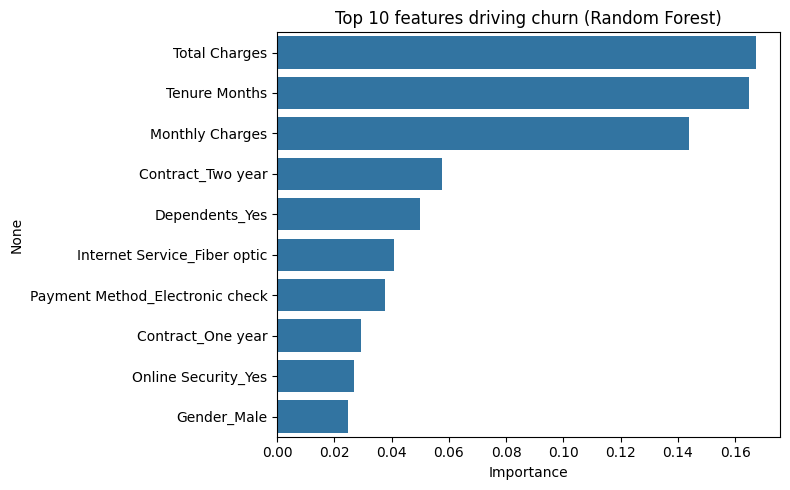

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# load + clean
df = pd.read_excel("Telco_customer_churn.xlsx")
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce").fillna(0)

drop_cols = ["CustomerID", "Count", "Country", "State", "City", "Zip Code",
             "Lat Long", "Latitude", "Longitude",
             "Churn Value", "Churn Score", "CLTV", "Churn Reason"]
data = df.drop(columns=drop_cols)
data["Churn Label"] = data["Churn Label"].map({"Yes": 1, "No": 0})
data = pd.get_dummies(data, drop_first=True)
X = data.drop("Churn Label", axis=1)
y = data["Churn Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

# threshold tuning
probs = rf.predict_proba(X_test)[:, 1]
for t in [0.5, 0.4, 0.35, 0.3, 0.25]:
    pred = (probs >= t).astype(int)
    print(f"Threshold {t}: precision={precision_score(y_test, pred):.2f}, "
          f"recall={recall_score(y_test, pred):.2f}, f1={f1_score(y_test, pred):.2f}")

# feature importance
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top10 = imp.head(10)
print(top10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 features driving churn (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()